# Model Comparison & Evaluation Dashboard


## 1. Imports

In [40]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
import xgboost as xgb
import gc

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)

## 2. Config


In [41]:
DATA_PATH = Path.cwd().parent / "data" / "model_input" / "df_model_input.csv" 
OUTPUT_DIR = Path("outputs/model_comparison")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    ("decision_tree", "firm"):              Path.cwd().parent / "model" / "firm_rf_model.pkl",
    ("decision_tree", "firm_survey"):       Path.cwd().parent / "model" / "firm_survey_rf_model.pkl",
    ("decision_tree", "firm_survey_text"):  Path.cwd().parent / "model" / "firm_survey_text_rf_model.pkl",
    ("xgboost", "firm"):                    Path.cwd().parent / "model" / "firm_xgboost_model.pkl",
    ("xgboost", "firm_survey"):             Path.cwd().parent / "model" / "firm_survey_xgboost_model.pkl",
    ("xgboost", "firm_survey_text"):        Path.cwd().parent / "model" / "firm_survey_text_xgboost_model.pkl",
    ("mlp", "firm"):                        Path.cwd().parent / "model" / "firm_nn_model.pkl",
    ("mlp", "firm_survey"):                 Path.cwd().parent / "model" / "firm_survey_nn_model.pkl",
    ("mlp", "firm_survey_text"):            Path.cwd().parent / "model" / "firm_survey_text_nn_model.pkl",
}

MODEL_TYPES = ["decision_tree", "xgboost", "mlp"]
MODEL_LABELS = {"decision_tree": "Decision Tree", "xgboost": "XGBoost", "mlp": "Neural Network"}
FEATURE_SETS = ["firm", "firm_survey", "firm_survey_text"]
FEATURE_SET_LABELS = {
    "firm": "Firm only",
    "firm_survey": "Firm + Survey",
    "firm_survey_text": "Firm + Survey + Text",
}

ID_COL = "idnr"
YEAR_COL = "closdate_year"         
TARGET_COL = "ncliGrowthNextYear"
NAICS_COL = "naics_core_code"
TOAS_COL = "toas"                 # total assets, used for size buckets + SME filter
NCLI_COL = "ncli"                 # non-current liabilities level
CULI_COL = "culi"                 # current liabilities 

# ---- split, matching your existing CV/test setup -----------------------
TEST_YEARS = [2020, 2021, 2022]
SME_ASSET_THRESHOLD = 43_000  # in thousands EUR (43M), per NRW.BANK SME definition

RANDOM_STATE = 42

## 3. Load data and rebuild the train/test split

In [42]:
df = pd.read_csv(DATA_PATH)

In [43]:
# Reproduce feature engineering steps
def safe_ratio(
    numerator: pd.Series,
    denominator: pd.Series,
    *,
    require_positive_denominator: bool = True,
) -> pd.Series:
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")
    valid = numerator.notna() & denominator.notna()
    if require_positive_denominator:
        valid &= denominator > 0
    else:
        valid &= denominator != 0
    out = pd.Series(np.nan, index=numerator.index, dtype="float32")
    out.loc[valid] = (numerator.loc[valid] / denominator.loc[valid]).astype("float32")
    return out.replace([np.inf, -np.inf], np.nan)

# Sort once so all lagged firm features use only t and earlier observations.
df = df.sort_values([ID_COL, YEAR_COL]).copy()
firm_group = df.groupby(ID_COL, sort=False)
lag_year = firm_group[YEAR_COL].shift(1)
consecutive = (df[YEAR_COL] - lag_year).eq(1)

# -----------------------------------------------------------------------------
# Ratios based on documented balance-sheet identities. No full-sample
# clipping is performed here; fold-fitted winsorization is applied later.
# -----------------------------------------------------------------------------
if {"cuas", "culi"}.issubset(df.columns):
    df["current_ratio_clean"] = safe_ratio(df["cuas"], df["culi"])
    df["log1p_current_ratio_clean"] = np.log1p(
        df["current_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"cuas", "stok", "culi"}.issubset(df.columns):
    quick_assets = df["cuas"] - df["stok"]
    df["quick_ratio_clean"] = safe_ratio(quick_assets, df["culi"])
    df["log1p_quick_ratio_clean"] = np.log1p(
        df["quick_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"shfd", "toas"}.issubset(df.columns):
    df["solvency_ratio_clean"] = safe_ratio(df["shfd"], df["toas"])

if {"ncli", "loan", "shfd"}.issubset(df.columns):
    # Gearing is undefined or difficult to interpret with non-positive equity.
    gearing_num = df["ncli"] + df["loan"]
    df["gearing_ratio_clean"] = safe_ratio(gearing_num, df["shfd"])
    df["log1p_gearing_ratio_clean"] = np.log1p(
        df["gearing_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"ncli", "culi", "toas"}.issubset(df.columns):
    df["liabilities_to_assets"] = safe_ratio(df["ncli"] + df["culi"], df["toas"])

if {"wkca", "toas"}.issubset(df.columns):
    df["working_capital_to_assets"] = safe_ratio(
        df["wkca"], df["toas"], require_positive_denominator=True
    )

if {"stok", "cuas"}.issubset(df.columns):
    valid = (df["cuas"] > 0) & (df["stok"] >= 0) & (df["stok"] <= df["cuas"])
    df["inventory_share_current_assets"] = np.where(
        valid, df["stok"] / df["cuas"], np.nan
    ).astype("float32")

if {"debt", "cuas"}.issubset(df.columns):
    valid = (df["cuas"] > 0) & (df["debt"] >= 0) & (df["debt"] <= df["cuas"])
    df["receivables_share_current_assets"] = np.where(
        valid, df["debt"] / df["cuas"], np.nan
    ).astype("float32")

if {"cash", "toas"}.issubset(df.columns):
    valid = (df["toas"] > 0) & (df["cash"] >= 0) & (df["cash"] <= df["toas"])
    df["cash_to_assets"] = np.where(valid, df["cash"] / df["toas"], np.nan).astype("float32")

if {"fias", "toas"}.issubset(df.columns):
    valid = (df["toas"] > 0) & (df["fias"] >= 0) & (df["fias"] <= df["toas"])
    df["fixed_assets_share"] = np.where(valid, df["fias"] / df["toas"], np.nan).astype("float32")

if {"ltdb", "ncli"}.issubset(df.columns):
    valid = (df["ncli"] > 0) & (df["ltdb"] >= 0) & (df["ltdb"] <= df["ncli"])
    df["ltdb_share_of_ncli"] = np.where(valid, df["ltdb"] / df["ncli"], np.nan).astype("float32")

# -----------------------------------------------------------------------------
# Stable changes in firm levels. These replace unstable cash percentage growth
# and make the time direction explicit.
# -----------------------------------------------------------------------------
if "log_toas" not in df.columns and "toas" in df.columns:
    df["log_toas"] = np.log1p(df["toas"].clip(lower=0)).astype("float32")
if "log_empl" not in df.columns and "empl" in df.columns:
    df["log_empl"] = np.log1p(df["empl"].clip(lower=0)).astype("float32")

if "log_toas" in df.columns:
    lag_log_toas = firm_group["log_toas"].shift(1)
    df["log_toas_change_clean"] = np.where(
        consecutive, df["log_toas"] - lag_log_toas, np.nan
    ).astype("float32")

if {"cash", "toas"}.issubset(df.columns):
    lag_cash = firm_group["cash"].shift(1)
    lag_toas = firm_group["toas"].shift(1)
    valid = consecutive & lag_toas.gt(0)
    df["cash_change_to_lagged_assets"] = np.where(
        valid, (df["cash"] - lag_cash) / lag_toas, np.nan
    ).astype("float32")

if "ncliGrowthThisYear" in df.columns:
    rolling_volatility = (
        df.groupby(ID_COL, sort=False)["ncliGrowthThisYear"]
          .rolling(window=3, min_periods=2)
          .std()
          .reset_index(level=0, drop=True)
    )
    df["ncli_growth_volatility_3y"] = rolling_volatility.astype("float32")

# -----------------------------------------------------------------------------
# Macro transformations.
# Confidence balances can cross zero, so use first differences.
# Positive indices use percentage changes calculated from annual levels.
# -----------------------------------------------------------------------------
BALANCE_LEVELS = [
    "de_construction_confidence",
    "de_consumer_confidence",
    "de_industry_confidence",
    "de_retail_confidence",
    "de_services_confidence",
]
POSITIVE_INDEX_LEVELS = [
    "de_economic_sentiment_index",
    "de_employment_expectations_index",
    "ifo_business_climate",
    "ifo_business_expectations",
    "ifo_business_situation",
]

available_macro_levels = [
    c for c in BALANCE_LEVELS + POSITIVE_INDEX_LEVELS if c in df.columns
]
if available_macro_levels:
    annual_macro = (
        df.groupby(YEAR_COL, sort=True)[available_macro_levels]
          .median(numeric_only=True)
          .sort_index()
    )

    for col in [c for c in BALANCE_LEVELS if c in annual_macro.columns]:
        new_col = f"{col}_change_clean"
        year_values = annual_macro[col].diff()
        df[new_col] = df[YEAR_COL].map(year_values).astype("float32")

    for col in [c for c in POSITIVE_INDEX_LEVELS if c in annual_macro.columns]:
        new_col = f"{col}_pct_change_clean"
        current = annual_macro[col]
        previous = current.shift(1)
        year_values = ((current / previous) - 1).where((current > 0) & (previous > 0))
        df[new_col] = df[YEAR_COL].map(year_values).astype("float32")

# -----------------------------------------------------------------------------
# Text counts are used only if a document-length variable exists. Otherwise,
# raw lm_positive/lm_negative counts are omitted and polarity/ratios are used.
# -----------------------------------------------------------------------------
TOKEN_COUNT_CANDIDATES = [
    "token_count", "n_tokens", "word_count", "total_words", "document_length"
]
token_count_col = next((c for c in TOKEN_COUNT_CANDIDATES if c in df.columns), None)
if token_count_col is not None:
    for source, target in [
        ("lm_positive", "lm_positive_frequency"),
        ("lm_negative", "lm_negative_frequency"),
    ]:
        if source in df.columns:
            df[target] = safe_ratio(df[source], df[token_count_col])
    print(f"Normalized sentiment counts using: {token_count_col}")
else:
    print("No document-length column found: raw positive/negative counts will be omitted.")

# Replace any remaining infinities and downcast new floating-point columns.
float64_cols = df.select_dtypes(include="float64").columns
df[float64_cols] = df[float64_cols].astype("float32")
df.replace([np.inf, -np.inf], np.nan, inplace=True)

del firm_group, lag_year, consecutive
gc.collect()


No document-length column found: raw positive/negative counts will be omitted.


576

In [44]:
def present(columns: list[str]) -> list[str]:
    return [c for c in columns if c in df.columns]

CATEGORY_COLS = present(["naics_2digit", "type"])

FIRM_NUMERIC_CANDIDATES = [
    "log_toas",
    "log_empl",                 # raw empl is intentionally omitted
    "firm_age",
    "years_in_panel",
    "is_na_empl",
    "ncliGrowthThisYear",
    "log_toas_change_clean",
    "cash_change_to_lagged_assets",
    "ncli_growth_volatility_3y",
    "log1p_current_ratio_clean",
    "log1p_quick_ratio_clean",
    "solvency_ratio_clean",
    "log1p_gearing_ratio_clean",
    "liabilities_to_assets",
    "working_capital_to_assets",
    "inventory_share_current_assets",
    "receivables_share_current_assets",
    "cash_to_assets",
    "fixed_assets_share",
    "ltdb_share_of_ncli",
]
FIRM_FEATURES = present(FIRM_NUMERIC_CANDIDATES) + CATEGORY_COLS

SURVEY_LEVEL_FEATURES = present(BALANCE_LEVELS + POSITIVE_INDEX_LEVELS)
SURVEY_CHANGE_FEATURES = present(
    [f"{c}_change_clean" for c in BALANCE_LEVELS]
    + [f"{c}_pct_change_clean" for c in POSITIVE_INDEX_LEVELS]
)
SURVEY_FEATURES = SURVEY_LEVEL_FEATURES + SURVEY_CHANGE_FEATURES

TEXT_FEATURES = present([
    "lm_polarity",
    "uncertainty_ratio",
    "litigious_ratio",
    "constraining_ratio",
    "strong_modal_ratio",
    "weak_modal_ratio",
    "lm_positive_frequency",
    "lm_negative_frequency",
])


In [45]:
train_df = df[df[YEAR_COL] < TEST_YEARS[0]].copy()
test_df = df[df[YEAR_COL].isin(TEST_YEARS)].copy()

ybar_train = train_df[TARGET_COL].mean()

print(f"Train: {len(train_df):,} firm-years ({train_df[YEAR_COL].min()}-{train_df[YEAR_COL].max()})")
print(f"Test:  {len(test_df):,} firm-years ({sorted(test_df[YEAR_COL].unique())})")
print(f"Train-mean baseline (ybar_train): {ybar_train:.4f}")

Train: 1,113,369 firm-years (2010-2019)
Test:  630,228 firm-years ([np.int64(2020), np.int64(2021), np.int64(2022)])
Train-mean baseline (ybar_train): -0.0689


In [46]:
# Add QuantileWinsorizer class to match the one used in XGBoost and Neural Network pipelines
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class QuantileWinsorizer(BaseEstimator, TransformerMixin):
    """Clip numeric features using quantiles learned on the training data only."""

    def __init__(self, lower_quantile: float = 0.01, upper_quantile: float = 0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile

    @staticmethod
    def _as_array(X) -> np.ndarray:
        if hasattr(X, "to_numpy"):
            return X.to_numpy(dtype=np.float32, copy=True)
        return np.asarray(X, dtype=np.float32)

    def fit(self, X, y=None):
        values = self._as_array(X)
        self.n_features_in_ = values.shape[1]
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            lower = np.nanquantile(values, self.lower_quantile, axis=0)
            upper = np.nanquantile(values, self.upper_quantile, axis=0)
        self.lower_bounds_ = np.where(np.isfinite(lower), lower, -np.inf).astype(np.float32)
        self.upper_bounds_ = np.where(np.isfinite(upper), upper, np.inf).astype(np.float32)
        return self
    def transform(self, X):
        return np.clip(self._as_array(X), self.lower_bounds_, self.upper_bounds_)

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        if hasattr(self, "feature_names_in_"):
            return self.feature_names_in_
        return np.asarray([f"x{i}" for i in range(self.n_features_in_)], dtype=object)
# joblib looks this up as __main__.QuantileWinsorizer when unpickling
import __main__
__main__.QuantileWinsorizer = QuantileWinsorizer

### 3.1 Firm-level grouping variables

In [47]:
def add_industry_size_leverage(frame: pd.DataFrame, size_cuts, lev_cuts) -> pd.DataFrame:
    out = frame.copy()
    out["is_sme"] = out[TOAS_COL] <= SME_ASSET_THRESHOLD
    out["leverage_ratio"] = (out[NCLI_COL] + out.get(CULI_COL, 0)) / out[TOAS_COL].replace(0, np.nan)
    out["size_tercile"] = pd.cut(out[TOAS_COL], bins=[-np.inf, *size_cuts, np.inf],
                                  labels=["Small", "Medium", "Large"])
    out["leverage_tercile"] = pd.cut(out["leverage_ratio"], bins=[-np.inf, *lev_cuts, np.inf],
                                      labels=["Low", "Medium", "High"])
    return out

size_cuts = train_df[TOAS_COL].quantile([1/3, 2/3]).values
_train_lev = (train_df[NCLI_COL] + train_df.get(CULI_COL, 0)) / train_df[TOAS_COL].replace(0, np.nan)
lev_cuts = _train_lev.quantile([1/3, 2/3]).values

test_df = add_industry_size_leverage(test_df, size_cuts, lev_cuts)
train_df = add_industry_size_leverage(train_df, size_cuts, lev_cuts)

print("Size tercile cutoffs (total assets, k EUR):", np.round(size_cuts, 1))
print("Leverage tercile cutoffs:", np.round(lev_cuts, 3))
test_df[["naics_2digit", "is_sme", "size_tercile", "leverage_tercile"]].describe(include="all").T

Size tercile cutoffs (total assets, k EUR): [1167.1 5618.5]
Leverage tercile cutoffs: [0.497 0.806]


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
naics_2digit,630228.0,NaN,NaN,NaN,45.131568,15.305743,11.0,33.0,48.0,54.0,92.0
is_sme,630228,2,True,448721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size_tercile,630228,3,Medium,246949,NaN,NaN,NaN,NaN,NaN,NaN,NaN
leverage_tercile,630228,3,Low,227975,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Load the 9 fitted pipelines

In [48]:
models = {}
for key, path in MODEL_PATHS.items():
    p = Path(path)
    if not p.exists():
        print(f"[MISSING] {key} -> {path}")
        continue
    # Keep the raw loaded object: a bare fitted Pipeline for decision_tree,
    # or a dict with "model" + metadata (feature_columns / category_levels) for xgboost/mlp.
    # unpack_model_entry() / predict() below know how to handle both.
    models[key] = joblib.load(p)

print(f"Loaded {len(models)} / {len(MODEL_PATHS)} models.")


Loaded 9 / 9 models.


## 5. Metrics and prediction helpers


In [49]:
from sklearn.base import BaseEstimator, RegressorMixin


def metrics(actual: np.ndarray, pred: np.ndarray) -> dict:
    ok = ~(np.isnan(actual) | np.isnan(pred))
    e = actual[ok] - pred[ok]
    return {
        "RMSE": float(np.sqrt(np.mean(e ** 2))),
        "MAE": float(np.mean(np.abs(e))),
        "n": int(ok.sum()),
    }


def r2_oos(actual: np.ndarray, pred: np.ndarray, ref: float) -> float:
    ok = ~(np.isnan(actual) | np.isnan(pred))
    a, p = actual[ok], pred[ok]
    ss_res = np.sum((a - p) ** 2)
    ss_tot = np.sum((a - ref) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan


def unpack_model_entry(entry):
    """Support both bare model objects and wrapped artifacts with metadata."""
    if isinstance(entry, dict) and "model" in entry:
        return entry["model"], entry
    return entry, {}


def prepare_model_frame(entry, frame: pd.DataFrame) -> pd.DataFrame:
    """Build the feature frame expected by the fitted model, including categorical levels.

    - decision_tree / mlp: bare Pipelines with an internal ColumnTransformer, so no
      metadata is needed -- they select/encode their own columns from the full frame.
    - xgboost: a bare XGBRegressor fit with enable_categorical=True, so it needs the
      exact feature_columns AND the categorical columns cast to the training categories.
    """
    _, metadata = unpack_model_entry(entry)
    feature_columns = metadata.get("feature_columns")
    category_levels = metadata.get("category_levels", {})

    X = frame[feature_columns].copy() if feature_columns is not None else frame.copy()

    for col, levels in category_levels.items():
        if col in X.columns:
            X[col] = pd.Categorical(X[col], categories=levels)
    return X


def required_columns(entry) -> list | None:
    """Feature list an entry expects: prefer metadata, fall back to feature_names_in_."""
    model, metadata = unpack_model_entry(entry)
    if metadata.get("feature_columns") is not None:
        return list(metadata["feature_columns"])
    if hasattr(model, "feature_names_in_"):
        return list(model.feature_names_in_)
    return None


def predict(entry, frame: pd.DataFrame) -> np.ndarray:
    """Predict with any models[key] entry -- bare Pipeline or dict-wrapped model."""
    model, _ = unpack_model_entry(entry)
    X = prepare_model_frame(entry, frame)
    return np.asarray(model.predict(X)).ravel()


class _EntryEstimator(BaseEstimator, RegressorMixin):
    """Thin adapter so a models[key] entry can be used wherever sklearn expects a
    fitted regressor, e.g. permutation_importance(). Inherits from BaseEstimator /
    RegressorMixin purely so sklearn's internal tag/type checks pass -- .fit() is a
    no-op since the wrapped entry is already fitted."""
    def __init__(self, entry):
        self.entry = entry

    def fit(self, X, y=None):
        return self 

    def predict(self, X):
        return predict(self.entry, X)


def score(actual, pred, ref) -> dict:
    m = metrics(actual, pred)
    m["R2_oos"] = r2_oos(actual, pred, ref)
    return m


## 6. Score every model on the frozen test set + baseline

In [50]:
y_test = test_df[TARGET_COL].values

# Baseline: always predict the training mean
baseline_pred = np.full(len(test_df), ybar_train)

rows = [{"model": "Baseline (train mean)", "feature_set": "-", **score(y_test, baseline_pred, ybar_train)}]

predictions = {}  # (model_type, feature_set) -> np.ndarray, for reuse in breakdowns below
for (model_type, feature_set), entry in models.items():
    pred = predict(entry, test_df)

    predictions[(model_type, feature_set)] = pred
    rows.append({
        "model": MODEL_LABELS[model_type],
        "feature_set": FEATURE_SET_LABELS[feature_set],
        **score(y_test, pred, ybar_train),
    })

overall_results = pd.DataFrame(rows).sort_values(["model", "feature_set"])
overall_results = overall_results[["model", "feature_set", "n", "RMSE", "MAE", "R2_oos"]]
overall_results.to_csv(OUTPUT_DIR / "overall_performance.csv", index=False)
overall_results.round(4)


,model,feature_set,n,RMSE,MAE,R2_oos
0,Baseline (train mean),-,630228,0.3779,0.2779,0.0000
2,Decision Tree,Firm + Survey,630228,0.3681,0.2759,0.0509
3,Decision Tree,Firm + Survey + Text,630228,0.3688,0.2771,0.0476
1,Decision Tree,Firm only,630228,0.3697,0.2774,0.0430
8,Neural Network,Firm + Survey,630228,0.3744,0.2786,0.0185
9,Neural Network,Firm + Survey + Text,630228,0.3778,0.2825,0.0005
7,Neural Network,Firm only,630228,0.3728,0.2815,0.0265
5,XGBoost,Firm + Survey,630228,0.3717,0.2817,0.0327
6,XGBoost,Firm + Survey + Text,630228,0.3724,0.2828,0.0286
4,XGBoost,Firm only,630228,0.3735,0.2847,0.0229


## 7. Performance by year

Checks whether 2020 (the COVID shock) is dragging down the pooled 2020–2022
number, consistent with your framing of the structural break.


                    model period  year       n      RMSE       MAE    R2_oos
44  Baseline (train mean)   Test  2021  225653  0.378759  0.278593  0.000000
45          Decision Tree   Test  2021  225653  0.369483  0.277488  0.048381
46                XGBoost   Test  2021  225653  0.373594  0.284082  0.027088
47         Neural Network   Test  2021  225653  0.376259  0.282565  0.013157
48  Baseline (train mean)   Test  2022  184816  0.367968  0.269026  0.000000
49          Decision Tree   Test  2022  184816  0.363110  0.272749  0.026228
50                XGBoost   Test  2022  184816  0.368806  0.280667 -0.004562
51         Neural Network   Test  2022  184816  0.375982  0.280908 -0.044037
52  Baseline (train mean)  Check  2023    1685  0.369082  0.272176  0.000000
53          Decision Tree  Check  2023    1685  0.377145  0.285254 -0.044171
54                XGBoost  Check  2023    1685  0.395981  0.306061 -0.151074
55         Neural Network  Check  2023    1685  0.378643  0.283270 -0.052480

,model,period,year,n,RMSE,MAE,R2_oos
0,Baseline (train mean),Train,2010,13132,0.4194,0.3098,0.0000
1,Decision Tree,Train,2010,13132,0.3867,0.2901,0.1498
2,XGBoost,Train,2010,13132,0.4088,0.3057,0.0501
3,Neural Network,Train,2010,13132,0.4067,0.3058,0.0597
4,Baseline (train mean),Train,2011,12950,0.4056,0.3001,0.0000
5,Decision Tree,Train,2011,12950,0.3778,0.2844,0.1323
6,XGBoost,Train,2011,12950,0.3960,0.2985,0.0469
7,Neural Network,Train,2011,12950,0.3932,0.2960,0.0601
8,Baseline (train mean),Train,2012,21695,0.3942,0.2905,0.0000
9,Decision Tree,Train,2012,21695,0.3703,0.2788,0.1178


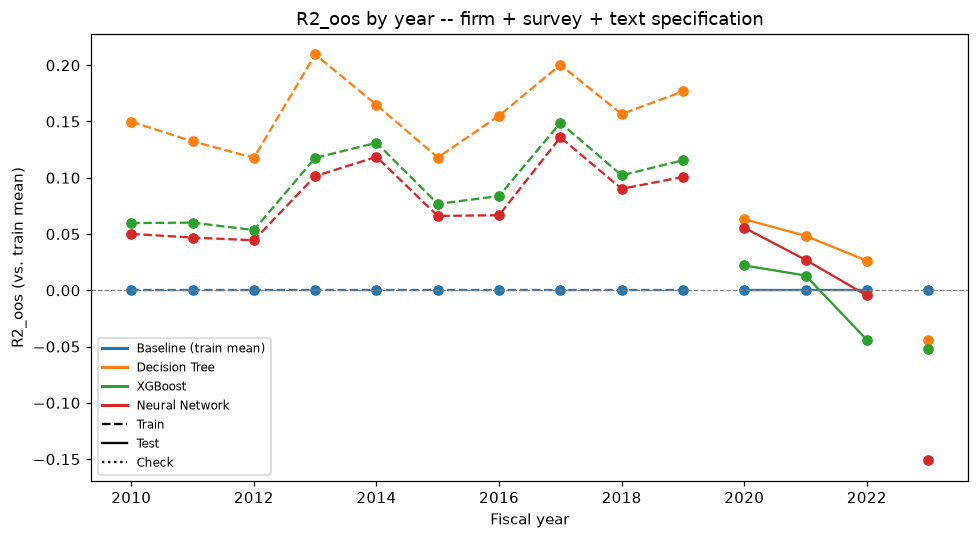

In [51]:
# ---- Score every model (firm_survey_text) across ALL years, including train + 2023 check ----
ALL_YEARS = sorted(df[YEAR_COL].dropna().unique())

# Predict on the full panel (not just test_df) so train years and 2023 are covered
full_predictions = {
    model_type: predict(models[(model_type, "firm_survey_text")], df)
    for model_type in MODEL_TYPES
}

by_year_rows = []
for year in ALL_YEARS:
    mask = df[YEAR_COL] == year
    y_year = df.loc[mask, TARGET_COL].values

    period = "Train" if year < TEST_YEARS[0] else ("Test" if year in TEST_YEARS else "Check")
    by_year_rows.append({"model": "Baseline (train mean)", "period": period, "year": year,
                          **score(y_year, np.full(mask.sum(), ybar_train), ybar_train)})
    for model_type, pred in full_predictions.items():
        by_year_rows.append({"model": MODEL_LABELS[model_type], "period": period, "year": year,
                              **score(y_year, pred[mask.values], ybar_train)})

by_year = pd.DataFrame(by_year_rows)[["model", "period", "year", "n", "RMSE", "MAE", "R2_oos"]]
by_year.to_csv(OUTPUT_DIR / "performance_by_year_all.csv", index=False)
print(by_year[by_year["year"] >= 2021])  # sanity-check n before trusting 2023

# ---- Plot: one color per model, linestyle per period ----
LINESTYLES = {"Train": "--", "Test": "-", "Check": ":"}

fig, ax = plt.subplots(figsize=(9, 5))
for label, grp in by_year.groupby("model"):
    grp = grp.sort_values("year")
    color = ax.plot(grp["year"], grp["R2_oos"], alpha=0)[0].get_color()  # reserve a color
    for period, style in LINESTYLES.items():
        seg = grp[grp["period"] == period]
        if not seg.empty:
            ax.plot(seg["year"], seg["R2_oos"], marker="o", color=color, linestyle=style)

# two simple legends: which color = which model, which linestyle = which period
model_legend = [plt.Line2D([0], [0], color=c, lw=2, label=m) for m, c in
                 zip(by_year["model"].unique(), plt.cm.tab10.colors)]
period_legend = [plt.Line2D([0], [0], color="black", linestyle=s, label=p) for p, s in LINESTYLES.items()]
ax.legend(handles=model_legend + period_legend, fontsize=8, loc="lower left")

ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("Fiscal year"); ax.set_ylabel("R2_oos (vs. train mean)")
ax.set_title("R2_oos by year -- firm + survey + text specification")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "r2_by_year_all.png")
by_year.round(4)

## 8. Feature-set contribution -- RQ1

The direct answer to "does survey/text sentiment improve forecasts": the
marginal change in `R2_oos` moving `firm` → `firm_survey` → `firm_survey_text`,
per model type.


,model,feature_set,R2_oos,delta_R2_oos_vs_firm_only
1,Decision Tree,Firm only,0.0430,0.0000
2,Decision Tree,Firm + Survey,0.0509,0.0078
3,Decision Tree,Firm + Survey + Text,0.0476,0.0045
7,Neural Network,Firm only,0.0265,0.0000
8,Neural Network,Firm + Survey,0.0185,-0.0081
9,Neural Network,Firm + Survey + Text,0.0005,-0.0261
4,XGBoost,Firm only,0.0229,0.0000
5,XGBoost,Firm + Survey,0.0327,0.0098
6,XGBoost,Firm + Survey + Text,0.0286,0.0057


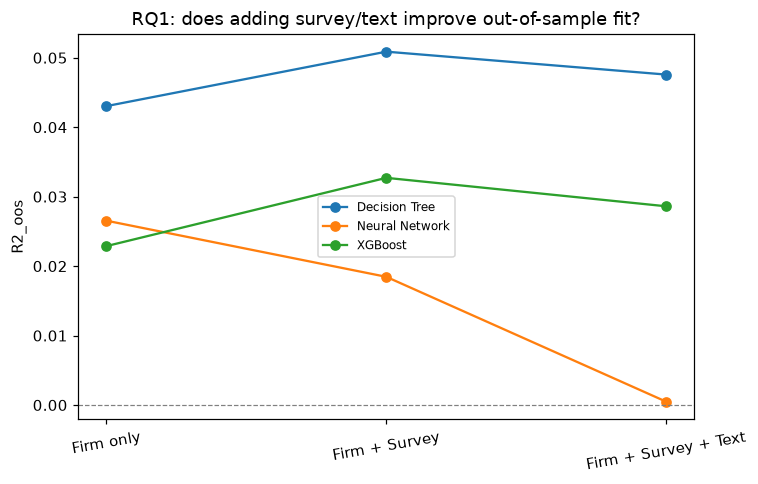

In [52]:
contribution = overall_results[overall_results["model"] != "Baseline (train mean)"].copy()
contribution["feature_set_order"] = contribution["feature_set"].map(
    {v: i for i, v in enumerate(FEATURE_SET_LABELS.values())}
)
contribution = contribution.sort_values(["model", "feature_set_order"])
contribution["delta_R2_oos_vs_firm_only"] = contribution.groupby("model")["R2_oos"].transform(lambda s: s - s.iloc[0])

fig, ax = plt.subplots(figsize=(7, 4.5))
for label, grp in contribution.groupby("model"):
    ax.plot(grp["feature_set"], grp["R2_oos"], marker="o", label=label)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_ylabel("R2_oos"); ax.set_title("RQ1: does adding survey/text improve out-of-sample fit?")
ax.legend(fontsize=8)
plt.xticks(rotation=10)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "rq1_feature_set_contribution.png")
contribution[["model", "feature_set", "R2_oos", "delta_R2_oos_vs_firm_only"]].round(4)

## 9. Feature importance, unified across models

- **Permutation importance** is computed the same way for every model type
  (model-agnostic, uses your `required_columns` helper) so results are
  directly comparable.

Run on the `firm_survey_text` model for each type, since that's the primary
specification for interpretation.


In [53]:
N_PERM_REPEATS = 10  # number of shuffles per feature for permutation importance. sklearn's default is 5, but we can afford more for stability.
PERM_SAMPLE_N = 20_000  # subsample the test set for permutation importance -- full-test permutation
                         # is expensive and not necessary for a stable ranking

perm_sample = test_df.sample(n=min(PERM_SAMPLE_N, len(test_df)), random_state=RANDOM_STATE)
y_perm = perm_sample[TARGET_COL].values

perm_importance_frames = []
native_importance_frames = []

for model_type in MODEL_TYPES:
    key = (model_type, "firm_survey_text")
    if key not in models:
        continue
    entry = models[key]
    model, _ = unpack_model_entry(entry)
    cols = required_columns(entry) or perm_sample.columns.tolist()
    X_perm = perm_sample[cols]

    # _EntryEstimator re-applies categorical casting (via prepare_model_frame) on every
    # shuffled column, which plain XGBRegressor.predict() would otherwise choke on.
    result = permutation_importance(
        _EntryEstimator(entry), X_perm, y_perm,
        n_repeats=N_PERM_REPEATS, random_state=RANDOM_STATE, scoring="neg_root_mean_squared_error",
    )
    perm_importance_frames.append(pd.DataFrame({
        "model": MODEL_LABELS[model_type],
        "feature": cols,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    }))


perm_importance = pd.concat(perm_importance_frames, ignore_index=True) if perm_importance_frames else pd.DataFrame()

perm_importance.to_csv(OUTPUT_DIR / "permutation_importance.csv", index=False)
perm_importance.head()


,model,feature,importance_mean,importance_std
0,Decision Tree,log_toas,0.001108,0.000166
1,Decision Tree,log_empl,0.000399,0.000049
2,Decision Tree,firm_age,0.000230,0.000037
3,Decision Tree,years_in_panel,0.000041,0.000020
4,Decision Tree,is_na_empl,-0.000057,0.000018


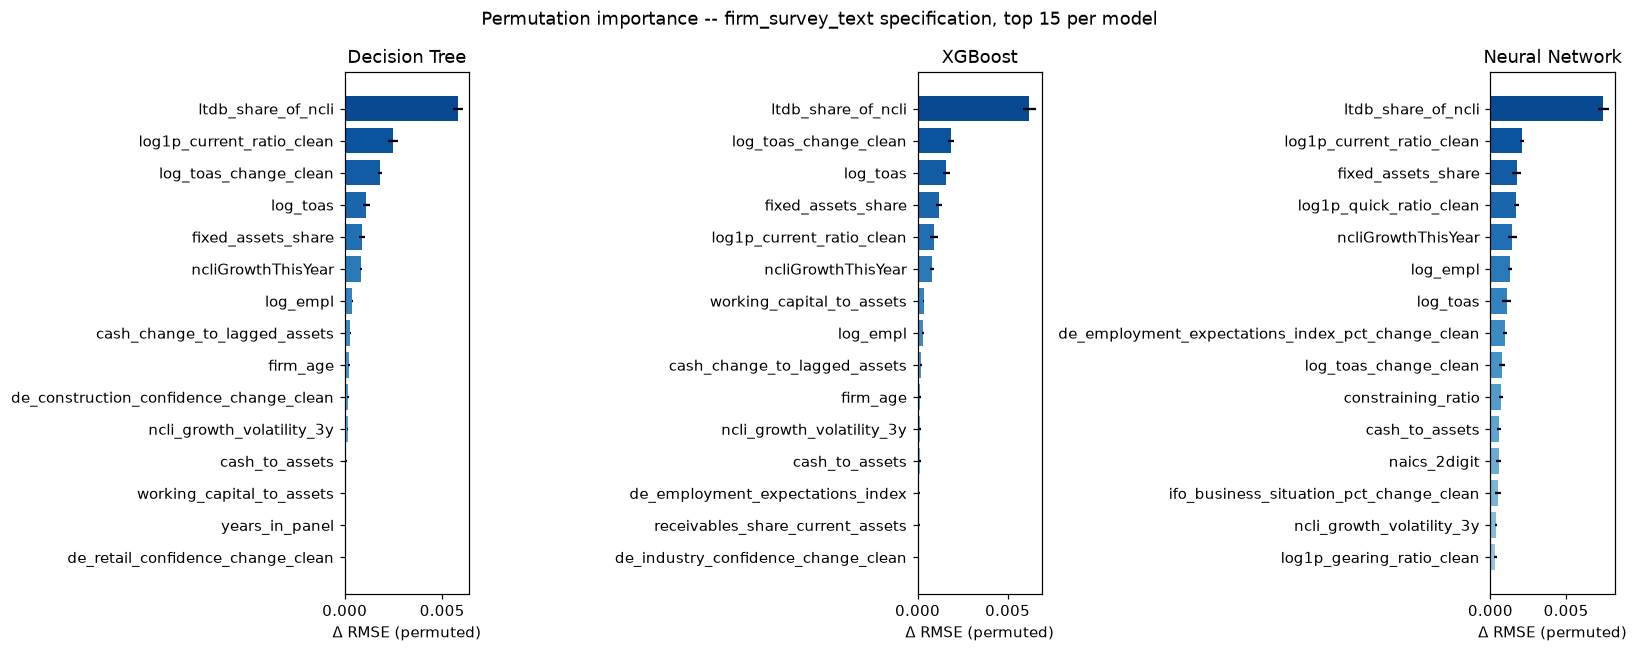

In [54]:
# Top-15 features by permutation importance, one panel per model
if not perm_importance.empty:
    fig, axes = plt.subplots(1, len(MODEL_TYPES), figsize=(5 * len(MODEL_TYPES), 6), sharex=False)
    if len(MODEL_TYPES) == 1:
        axes = [axes]
    for ax, model_type in zip(axes, MODEL_TYPES):
        label = MODEL_LABELS[model_type]
        sub = perm_importance[perm_importance["model"] == label].nlargest(15, "importance_mean")
        sub = sub.sort_values("importance_mean")
        ax.barh(sub["feature"], sub["importance_mean"], xerr=sub["importance_std"],
                color=plt.cm.Blues(np.linspace(0.4, 0.9, len(sub))))
        ax.set_title(label)
        ax.set_xlabel("Δ RMSE (permuted)")
    fig.suptitle("Permutation importance -- firm_survey_text specification, top 15 per model")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "permutation_importance_top15.png")

### 10.1 Group permutation importance for correlated macro clusters

Individual ifo/EC survey indices are highly collinear (per your data notes),
so permuting one at a time understates their joint contribution. This shuffles
the *entire macro block* together, and separately the *entire text block*, to
get a cleaner read on each information source as a whole -- directly useful
for RQ1.


In [55]:
MACRO_COLS = SURVEY_FEATURES
TEXT_COLS = TEXT_FEATURES

def group_permutation_importance(entry, frame: pd.DataFrame, y: np.ndarray,
                                   group_cols: list[str], n_repeats: int = 100) -> dict:
    cols = required_columns(entry) or frame.columns.tolist()
    group_cols = [c for c in group_cols if c in cols]
    if not group_cols:
        return {"delta_rmse_mean": np.nan, "delta_rmse_std": np.nan, "n_features_in_group": 0}
    X = frame[cols].copy()
    baseline_rmse = np.sqrt(np.mean((y - predict(entry, X)) ** 2))
    deltas = []
    rng = np.random.RandomState(RANDOM_STATE)
    for _ in range(n_repeats):
        X_shuffled = X.copy()
        perm_idx = rng.permutation(len(X_shuffled))
        X_shuffled[group_cols] = X_shuffled[group_cols].values[perm_idx]
        shuffled_rmse = np.sqrt(np.mean((y - predict(entry, X_shuffled)) ** 2))
        deltas.append(shuffled_rmse - baseline_rmse)
    return {"delta_rmse_mean": float(np.mean(deltas)), "delta_rmse_std": float(np.std(deltas)),
            "n_features_in_group": len(group_cols)}

group_rows = []
for model_type in MODEL_TYPES:
    key = (model_type, "firm_survey_text")
    if key not in models:
        continue
    entry = models[key]
    for group_name, group_cols in [("Macro (all)", MACRO_COLS), ("Text sentiment (all)", TEXT_COLS)]:
        stats = group_permutation_importance(entry, perm_sample, y_perm, group_cols)
        group_rows.append({"model": MODEL_LABELS[model_type], "feature_group": group_name, **stats})

group_importance = pd.DataFrame(group_rows)
group_importance.to_csv(OUTPUT_DIR / "group_permutation_importance.csv", index=False)
group_importance.round(4)


,model,feature_group,delta_rmse_mean,delta_rmse_std,n_features_in_group
0,Decision Tree,Macro (all),0.0002,0.0001,20
1,Decision Tree,Text sentiment (all),-0.0001,0.0001,6
2,XGBoost,Macro (all),0.0003,0.0001,20
3,XGBoost,Text sentiment (all),-0.0001,0.0000,6
4,Neural Network,Macro (all),0.0007,0.0004,20
5,Neural Network,Text sentiment (all),-0.0002,0.0002,6


## 11. Summary table for the exec summary / slides

In [56]:
summary = overall_results.copy()
summary["beats_baseline"] = summary["R2_oos"] > 0
print("=== Overall test-set performance (2020-2022) ===")
display(summary.round(4))

print("\n=== RQ1: feature-set contribution (delta R2_oos vs. firm-only, by model) ===")
display(contribution[["model", "feature_set", "R2_oos", "delta_R2_oos_vs_firm_only"]].round(4))

print("\n=== RQ2: heterogeneity summary (R2_oos range across size terciles, full spec) ===")
size_range = (by_size[by_size["feature_set"] == FEATURE_SET_LABELS["firm_survey_text"]]
              .groupby("model")["R2_oos"].agg(["min", "max"]))
display(size_range.round(4))

print(f"\nAll tables and figures written to: {OUTPUT_DIR.resolve()}")

=== Overall test-set performance (2020-2022) ===


,model,feature_set,n,RMSE,MAE,R2_oos,beats_baseline
0,Baseline (train mean),-,630228,0.3779,0.2779,0.0000,False
2,Decision Tree,Firm + Survey,630228,0.3681,0.2759,0.0509,True
3,Decision Tree,Firm + Survey + Text,630228,0.3688,0.2771,0.0476,True
1,Decision Tree,Firm only,630228,0.3697,0.2774,0.0430,True
8,Neural Network,Firm + Survey,630228,0.3744,0.2786,0.0185,True
9,Neural Network,Firm + Survey + Text,630228,0.3778,0.2825,0.0005,True
7,Neural Network,Firm only,630228,0.3728,0.2815,0.0265,True
5,XGBoost,Firm + Survey,630228,0.3717,0.2817,0.0327,True
6,XGBoost,Firm + Survey + Text,630228,0.3724,0.2828,0.0286,True
4,XGBoost,Firm only,630228,0.3735,0.2847,0.0229,True



=== RQ1: feature-set contribution (delta R2_oos vs. firm-only, by model) ===


,model,feature_set,R2_oos,delta_R2_oos_vs_firm_only
1,Decision Tree,Firm only,0.0430,0.0000
2,Decision Tree,Firm + Survey,0.0509,0.0078
3,Decision Tree,Firm + Survey + Text,0.0476,0.0045
7,Neural Network,Firm only,0.0265,0.0000
8,Neural Network,Firm + Survey,0.0185,-0.0081
9,Neural Network,Firm + Survey + Text,0.0005,-0.0261
4,XGBoost,Firm only,0.0229,0.0000
5,XGBoost,Firm + Survey,0.0327,0.0098
6,XGBoost,Firm + Survey + Text,0.0286,0.0057



=== RQ2: heterogeneity summary (R2_oos range across size terciles, full spec) ===


,min,max
model,,
Decision Tree,0.0369,0.0674
Neural Network,-0.0122,0.0208
XGBoost,0.0177,0.0469



All tables and figures written to: /home/huyn/MLforEcon/model/outputs/model_comparison


## 12. Performance by industry (2-digit NAICS) -- RQ2

Only industries with enough test-set observations are reported individually;
smaller ones are grouped into `Other` to avoid noisy single-digit-N rows.


,model,feature_set,industry,n,RMSE,MAE,R2_oos
0,Baseline (train mean),-,11,5612,0.3313,0.2346,0.0000
1,Decision Tree,Firm only,11,5612,0.3288,0.2380,0.0154
2,Decision Tree,Firm + Survey,11,5612,0.3258,0.2355,0.0330
3,Decision Tree,Firm + Survey + Text,11,5612,0.3260,0.2364,0.0322
4,XGBoost,Firm only,11,5612,0.3293,0.2430,0.0120
...,...,...,...,...,...,...,...
235,XGBoost,Firm + Survey,92,1013,0.3359,0.2461,0.0704
236,XGBoost,Firm + Survey + Text,92,1013,0.3364,0.2468,0.0679
237,Neural Network,Firm only,92,1013,0.3394,0.2465,0.0512
238,Neural Network,Firm + Survey,92,1013,0.3426,0.2493,0.0328


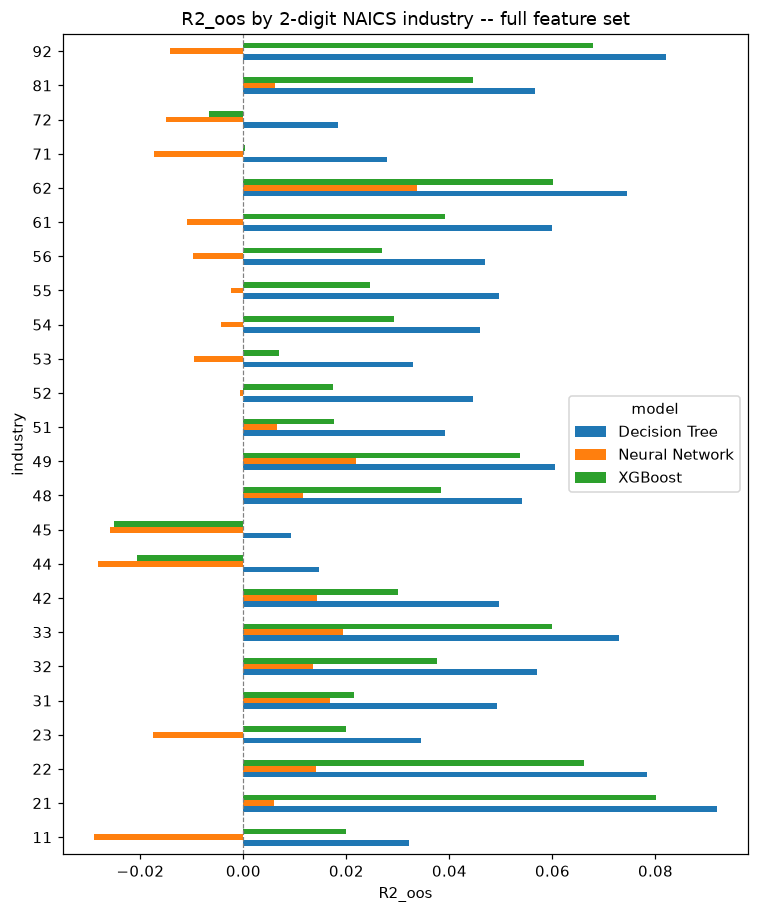

In [57]:
MIN_INDUSTRY_N = 500  # adjust based on your test-set sizes

industry_counts = test_df["naics_2digit"].value_counts()
keep_industries = industry_counts[industry_counts >= MIN_INDUSTRY_N].index
test_df["naics_2digit_grouped"] = np.where(
    test_df["naics_2digit"].isin(keep_industries), test_df["naics_2digit"], "Other"
)

by_industry_rows = []
for industry, mask in test_df.groupby("naics_2digit_grouped").groups.items():
    idx = test_df.index.get_indexer(mask)
    y_ind = test_df.loc[mask, TARGET_COL].values
    by_industry_rows.append({"model": "Baseline (train mean)", "feature_set": "-", "industry": industry,
                              **score(y_ind, np.full(len(mask), ybar_train), ybar_train)})
    for (model_type, feature_set), pred in predictions.items():
        by_industry_rows.append({
            "model": MODEL_LABELS[model_type],
            "feature_set": FEATURE_SET_LABELS[feature_set],
            "industry": industry,
            **score(y_ind, pred[idx], ybar_train),
        })

by_industry = pd.DataFrame(by_industry_rows)[["model", "feature_set", "industry", "n", "RMSE", "MAE", "R2_oos"]]
by_industry.to_csv(OUTPUT_DIR / "performance_by_industry.csv", index=False)

pivot = by_industry[by_industry["feature_set"] == FEATURE_SET_LABELS["firm_survey_text"]].pivot(
    index="industry", columns="model", values="R2_oos"
)
fig, ax = plt.subplots(figsize=(7, max(3, 0.35 * len(pivot))))
pivot.plot.barh(ax=ax)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("R2_oos"); ax.set_title("R2_oos by 2-digit NAICS industry -- full feature set")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "r2_by_industry.png")
by_industry.round(4)

## 9. Performance by firm size and leverage tercile -- RQ2

In [58]:
def score_by_group(group_col: str) -> pd.DataFrame:
    rows = []
    for grp_value, mask in test_df.groupby(group_col, observed=True).groups.items():
        idx = test_df.index.get_indexer(mask)
        y_grp = test_df.loc[mask, TARGET_COL].values
        rows.append({"model": "Baseline (train mean)", "feature_set": "-", group_col: grp_value,
                      **score(y_grp, np.full(len(mask), ybar_train), ybar_train)})
        for (model_type, feature_set), pred in predictions.items():
            rows.append({
                "model": MODEL_LABELS[model_type],
                "feature_set": FEATURE_SET_LABELS[feature_set],
                group_col: grp_value,
                **score(y_grp, pred[idx], ybar_train),
            })
    return pd.DataFrame(rows)[["model", "feature_set", group_col, "n", "RMSE", "MAE", "R2_oos"]]

by_size = score_by_group("size_tercile")
by_leverage = score_by_group("leverage_tercile")
by_sme = score_by_group("is_sme")

by_size.to_csv(OUTPUT_DIR / "performance_by_size.csv", index=False)
by_leverage.to_csv(OUTPUT_DIR / "performance_by_leverage.csv", index=False)
by_sme.to_csv(OUTPUT_DIR / "performance_by_sme.csv", index=False)

print("Size terciles:"); display(by_size[by_size["feature_set"] == FEATURE_SET_LABELS["firm_survey_text"]].round(4))
print("Leverage terciles:"); display(by_leverage[by_leverage["feature_set"] == FEATURE_SET_LABELS["firm_survey_text"]].round(4))
print("SME vs. non-SME:"); display(by_sme[by_sme["feature_set"] == FEATURE_SET_LABELS["firm_survey_text"]].round(4))

Size terciles:


,model,feature_set,size_tercile,n,RMSE,MAE,R2_oos
3,Decision Tree,Firm + Survey + Text,Small,171333,0.3847,0.2994,0.0398
6,XGBoost,Firm + Survey + Text,Small,171333,0.3881,0.3046,0.0227
9,Neural Network,Firm + Survey + Text,Small,171333,0.3936,0.3040,-0.0053
13,Decision Tree,Firm + Survey + Text,Medium,246949,0.3671,0.2784,0.0369
16,XGBoost,Firm + Survey + Text,Medium,246949,0.3707,0.2840,0.0177
19,Neural Network,Firm + Survey + Text,Medium,246949,0.3763,0.2831,-0.0122
23,Decision Tree,Firm + Survey + Text,Large,211946,0.3575,0.2578,0.0674
26,XGBoost,Firm + Survey + Text,Large,211946,0.3614,0.2639,0.0469
29,Neural Network,Firm + Survey + Text,Large,211946,0.3663,0.2644,0.0208


Leverage terciles:


,model,feature_set,leverage_tercile,n,RMSE,MAE,R2_oos
3,Decision Tree,Firm + Survey + Text,Low,227975,0.3870,0.2979,0.0471
6,XGBoost,Firm + Survey + Text,Low,227975,0.3909,0.3038,0.0279
9,Neural Network,Firm + Survey + Text,Low,227975,0.3992,0.3065,-0.0136
13,Decision Tree,Firm + Survey + Text,Medium,205027,0.3546,0.2651,0.0457
16,XGBoost,Firm + Survey + Text,Medium,205027,0.3589,0.2720,0.0225
19,Neural Network,Firm + Survey + Text,Medium,205027,0.3623,0.2692,0.0041
23,Decision Tree,Firm + Survey + Text,High,197226,0.3615,0.2656,0.0501
26,XGBoost,Firm + Survey + Text,High,197226,0.3643,0.2698,0.0356
29,Neural Network,Firm + Survey + Text,High,197226,0.3681,0.2686,0.0155


SME vs. non-SME:


,model,feature_set,is_sme,n,RMSE,MAE,R2_oos
3,Decision Tree,Firm + Survey + Text,False,181507,0.3593,0.2596,0.0710
6,XGBoost,Firm + Survey + Text,False,181507,0.3634,0.2659,0.0499
9,Neural Network,Firm + Survey + Text,False,181507,0.3677,0.2659,0.0273
13,Decision Tree,Firm + Survey + Text,True,448721,0.3726,0.2843,0.0385
16,XGBoost,Firm + Survey + Text,True,448721,0.3761,0.2897,0.0203
19,Neural Network,Firm + Survey + Text,True,448721,0.3818,0.2892,-0.0100
